In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Read the dataset
data = pd.read_csv('dataset/churn.csv')
data = data.drop(columns=['customer_id','country','gender'])

#pisahkan data fitur dan target
X = data.drop(columns=['churn'])
y = data['churn']

X.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [3]:
# normalisasi data supaya lebih gampang diproses
X = StandardScaler().fit_transform(X)

# bagi data menjadi train dan test split 60:20:20

# train nya 60% terus temp nya 40% dari awalnya 100%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
# val dan test nya masing-masing 20% dari awalnya 100% (jadi 50% dari temp)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Single Layer Perceptron

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)), # tambahin klo mw multilayer
])
# unit 1 --> 0 / 1
# sigmoid --> probability --> threshold (0.2)
# input_shape --> X_train.shape[1] --> jumlah fitur


/opt/homebrew/Caskroom/miniforge/base/envs/ai-core/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-10 23:07:55.895962: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-09-10 23:07:55.896219: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-10 23:07:55.896252: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-10 23:07:55.896974: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-10 23:07:55.897563: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_

In [5]:
# build model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
# train data
# history --> simpan loss dan hasil accuracy nya
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/100


2026-09-10 23:07:56.543672: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5270 - loss: 0.7770 - val_accuracy: 0.5710 - val_loss: 0.7123
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6122 - loss: 0.6757 - val_accuracy: 0.6560 - val_loss: 0.6302
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6758 - loss: 0.6043 - val_accuracy: 0.7145 - val_loss: 0.5733
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7445 - loss: 0.5555 - val_accuracy: 0.7835 - val_loss: 0.5354
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7928 - loss: 0.5221 - val_accuracy: 0.8030 - val_loss: 0.5085
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8090 - loss: 0.4988 - val_accuracy: 0.8105 - val_loss: 0.4901
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8100 - loss: 0.4823 - val_accuracy: 0.8065 - val_loss: 0.4769
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8095 - loss: 0.4706 - val_accuracy: 0.

In [7]:
# Prediction X_test sebanyak 5 data
predictions = model.predict(X_test[:5])
predictions_label = [1 if p >= 0.5 else 0 for p in predictions]
print(f'Predictions: {predictions_label}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
Predictions: [0, 0, 0, 0, 0]


In [8]:
# evaluasi dengan hitung loss dan accuracy di data test
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8125 - loss: 0.4358
Test Loss: 0.43580377101898193
Test Accuracy: 0.8125


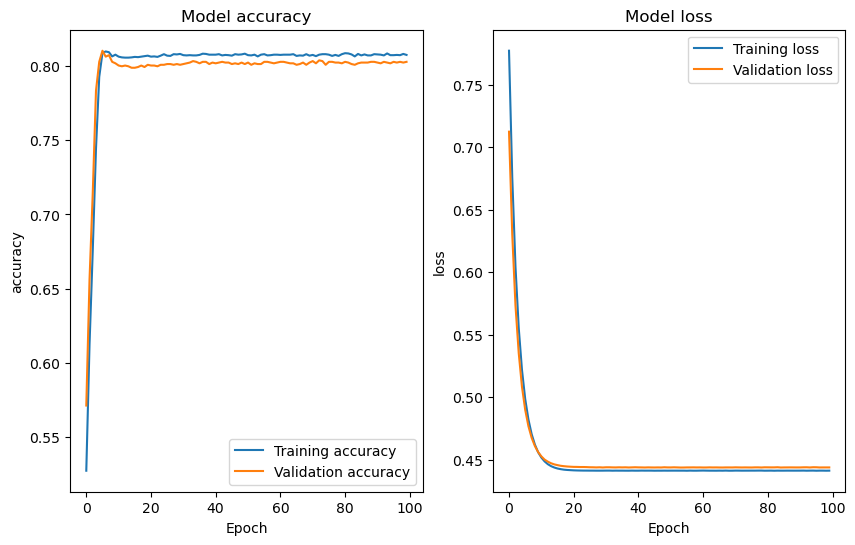

In [9]:
# plotting

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

# Multi Layer Perceptron

In [10]:
# without dropout
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [11]:
# build model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [12]:
# train data
# history --> simpan loss dan hasil accuracy nya
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7815 - loss: 0.4808 - val_accuracy: 0.8080 - val_loss: 0.4626
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7943 - loss: 0.4809 - val_accuracy: 0.7245 - val_loss: 0.7691
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7670 - loss: 0.6182 - val_accuracy: 0.7965 - val_loss: 0.4644
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7612 - loss: 0.7083 - val_accuracy: 0.7245 - val_loss: 1.1119
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7290 - loss: 1.0775 - val_accuracy: 0.6940 - val_loss: 1.2293
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7005 - loss: 2.3128 - val_accuracy: 0.7905 - val_loss: 0.8781
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7222 - loss: 1.8834 - val_accuracy: 0.6710 - val_loss: 2.1029
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6855 - loss: 4.5893 - 

In [13]:
# Prediction X_test sebanyak 5 data
predictions = model.predict(X_test[:5])
predictions_label = [1 if p >= 0.5 else 0 for p in predictions]
print(f'Predictions: {predictions_label}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
Predictions: [0, 0, 0, 0, 0]


In [14]:
# evaluasi dengan hitung loss dan accuracy di data test
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8210 - loss: 1153.2593
Test Loss: 1153.25927734375
Test Accuracy: 0.8209999799728394


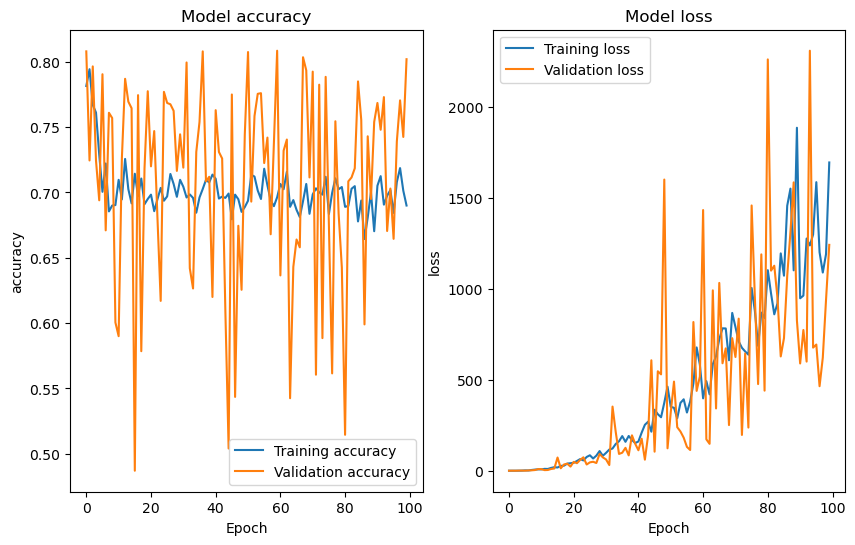

In [15]:
# plotting

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [16]:
# with dropout
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.005) , input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5), #supaya ga overfitting jadi dari 128 neuron kita drop 50% jadi 64 neuron
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)),
    tf.keras.layers.Dropout(0.5), #supaya ga overfitting jadi dari 64 neuron kita drop 50% jadi 32 neuron
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [17]:
# build model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
# train data
# history --> simpan loss dan hasil accuracy nya
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7450 - loss: 1.0650 - val_accuracy: 0.7970 - val_loss: 0.8228
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7902 - loss: 0.7298 - val_accuracy: 0.7885 - val_loss: 0.6406
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7917 - loss: 0.6056 - val_accuracy: 0.7925 - val_loss: 0.5685
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7908 - loss: 0.5803 - val_accuracy: 0.7855 - val_loss: 0.5869
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7923 - loss: 0.6985 - val_accuracy: 0.7810 - val_loss: 0.8494
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7875 - loss: 1.0995 - val_accuracy: 0.7910 - val_loss: 1.3671
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7642 - loss: 2.0553 - val_accuracy: 0.7975 - val_loss: 2.1918
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7450 - loss: 2.9339 - 

In [19]:
# Prediction X_test sebanyak 5 data
predictions = model.predict(X_test[:5])
predictions_label = [1 if p >= 0.5 else 0 for p in predictions]
print(f'Predictions: {predictions_label}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Predictions: [1, 1, 0, 1, 0]


In [20]:
# evaluasi dengan hitung loss dan accuracy di data test
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5630 - loss: 1652.2820
Test Loss: 1652.281982421875
Test Accuracy: 0.5630000233650208


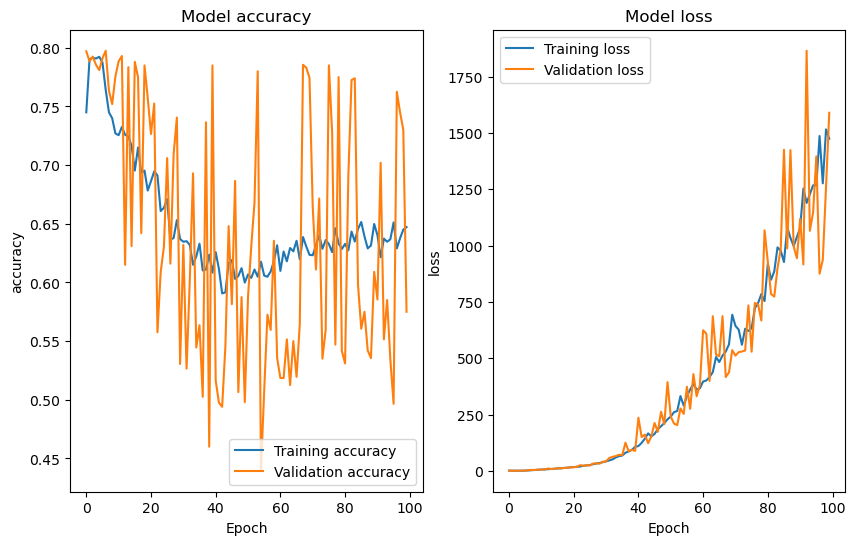

In [21]:
# plotting

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()